# Ensemble Model

## Import Libraries

In [ ]:
! pip install shap
! pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=042207a216cd53812dbc827011a9e9e8997377d84fe0c80fc2bed66573184ff4
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, accuracy_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from lime import lime_tabular

# Load Data and Merge Data

In [ ]:
drive.mount('/content/drive')

df_file_path = '/content/drive/My Drive/BT4222/data/df_feature_engineering.parquet'
xgboost_file_path = '/content/drive/My Drive/BT4222/data/xgboost_predictions.csv'
mlp_file_path = '/content/drive/My Drive/BT4222/data/mlp_predictions.csv'
lstm_file_path = '/content/drive/My Drive/BT4222/data/lstm_predictions.csv'
bert_file_path = '/content/drive/My Drive/BT4222/data/bert_predictions.csv'

df = pd.read_parquet(df_file_path)
xgboost_pred = pd.read_csv(xgboost_file_path)
mlp_pred = pd.read_csv(mlp_file_path)
lstm_pred = pd.read_csv(lstm_file_path)
bert_pred = pd.read_csv(bert_file_path)

Mounted at /content/drive


## Label Encoding
We encode the labels with integers 0-5 instead, in order of their truthfulness with
- 0: 'pants-fire'
- 1: 'false'
- 2: 'barely-true'
- 3: 'half-true'
- 4: 'mostly-true'
- 5: 'true'

In [ ]:
# mapping it in the order of pants-fire, false, barely-true, half-true, mostly-true, true
label_order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
label2idx = {label: idx for idx, label in enumerate(label_order)}
idx2label = {idx: label for label, idx in label2idx.items()}
df['label_encoded'] = df['label'].map(label2idx)

df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity,label_encoded
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,"[-0.012083505280315876, 0.04291439801454544, -...","[-0.00025620736414566636, 0.07373839616775513,...",31,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.09551206976175308, 0.009169962257146835, 0...",0.136364,0.455,3
1,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,0,"[0.038615476340055466, 0.09793295711278915, -0...","[0.018359245732426643, -0.0027450439520180225,...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.024317895993590355, -0.01789085566997528, ...",0.000000,0.000,0
2,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,1,"[0.008107000961899757, 0.016036679968237877, -...","[-0.053375788033008575, 0.08707486093044281, -...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.06791266053915024, -0.015540316700935364, ...",0.000000,0.000,5
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,0,"[-0.05084792524576187, 0.031769607216119766, 0...","[-0.01470591127872467, 0.015529205091297626, 0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.10175436735153198, -0.002838208107277751, ...",0.136364,0.455,2
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,0,"[-0.10781728476285934, 0.017993967980146408, 0...","[0.02528245933353901, 0.005831953138113022, -0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.03631351888179779, 0.039651136845350266, -...",0.068182,0.290,0


### Rename columns to standardize column names for predicted probabilites from different models for easier merging and analysis

In [ ]:
xgboost_pred.rename(columns={'reliability_probability': 'xgboost_prob'}, inplace=True)
xgboost_pred.head()

,id,xgboost_prob
0,7874.json,0.540882
1,2287.json,0.533582
2,13412.json,0.521522
3,2426.json,0.482448
4,4832.json,0.459244


In [ ]:
mlp_pred.rename(columns={'predicted_probability': 'mlp_prob'}, inplace=True)
mlp_pred.head()

,id,mlp_prob
0,7874.json,0.406662
1,13412.json,0.359861
2,2287.json,0.375574
3,2426.json,0.347714
4,4832.json,0.348989


In [ ]:
lstm_pred = lstm_pred.rename(columns={'class_0': 'lstm_pants_fire_prob', 'class_1': 'lstm_false_prob',
                                      'class_2': 'lstm_barely_true_prob', 'class_3': 'lstm_half_true_prob',
                                      'class_4': 'lstm_mostly_true_prob', 'class_5': 'lstm_true_prob'})
lstm_pred.drop(columns=["Unnamed: 0"], inplace=True)
lstm_pred.head()

,lstm_pants_fire_prob,lstm_false_prob,lstm_barely_true_prob,lstm_half_true_prob,lstm_mostly_true_prob,lstm_true_prob,id
0,0.116896,0.331581,0.168596,0.143390,0.104744,0.134793,7874.json
1,0.078231,0.288405,0.179340,0.186085,0.137927,0.130011,13412.json
2,0.547955,0.228645,0.110808,0.046633,0.022111,0.043848,2287.json
3,0.067088,0.274327,0.297814,0.242492,0.079598,0.038679,2426.json
4,0.159861,0.459021,0.105772,0.091125,0.097065,0.087156,4832.json


In [ ]:
bert_pred = bert_pred.rename(columns={'prob_class_0': 'bert_pants_fire_prob', 'prob_class_1': 'bert_false_prob',
                                      'prob_class_2': 'bert_barely_true_prob', 'prob_class_3': 'bert_half_true_prob',
                                      'prob_class_4': 'bert_mostly_true_prob', 'prob_class_5': 'bert_true_prob'})
# Append ".json" to the id column in bert_pred
bert_pred['id'] = bert_pred['id'].astype(str) + '.json'
bert_pred.head()

,id,bert_pants_fire_prob,bert_false_prob,bert_barely_true_prob,bert_half_true_prob,bert_mostly_true_prob,bert_true_prob
0,7232.json,0.001877,0.014722,0.023594,0.075747,0.423318,0.460742
1,7315.json,0.005652,0.018557,0.401128,0.291488,0.238283,0.044892
2,8673.json,0.003388,0.025443,0.015042,0.198322,0.213027,0.544778
3,9869.json,0.004748,0.005783,0.023229,0.130204,0.668099,0.167937
4,6026.json,0.003873,0.032810,0.042953,0.498556,0.250936,0.170871


## Merge Data into a single dataframe
Merge predictions from different models into a singular dataframe which allows us to use predictions from multiple models as features for our ensemble model

In [ ]:
# Merge step by step based on 'id'
merged_df = xgboost_pred[['id', 'xgboost_prob']].merge(
    mlp_pred[['id', 'mlp_prob']], on='id', how='inner'
).merge(
    lstm_pred[['id'] + lstm_pred.filter(regex='lstm_.*_prob').columns.tolist()], on='id', how='inner'
).merge(
    bert_pred[['id'] + bert_pred.filter(regex='bert_.*_prob').columns.tolist()], on='id', how='inner'
)

merged_df.head()

,id,xgboost_prob,mlp_prob,lstm_pants_fire_prob,lstm_false_prob,lstm_barely_true_prob,lstm_half_true_prob,lstm_mostly_true_prob,lstm_true_prob,bert_pants_fire_prob,bert_false_prob,bert_barely_true_prob,bert_half_true_prob,bert_mostly_true_prob,bert_true_prob
0,7874.json,0.540882,0.406662,0.116896,0.331581,0.168596,0.143390,0.104744,0.134793,0.004940,0.024119,0.012435,0.250663,0.330175,0.377668
1,2287.json,0.533582,0.375574,0.547955,0.228645,0.110808,0.046633,0.022111,0.043848,0.351809,0.547319,0.032236,0.027506,0.007356,0.033775
2,13412.json,0.521522,0.359861,0.078231,0.288405,0.179340,0.186085,0.137927,0.130011,0.004807,0.040617,0.023591,0.252860,0.165580,0.512545
3,2426.json,0.482448,0.347714,0.067088,0.274327,0.297814,0.242492,0.079598,0.038679,0.033867,0.248394,0.437425,0.251482,0.019332,0.009500
4,4832.json,0.459244,0.348989,0.159861,0.459021,0.105772,0.091125,0.097065,0.087156,0.411629,0.319393,0.136163,0.098556,0.013733,0.020526


In [ ]:
y = df['label_encoded']
y.head()

,label_encoded
0,3
1,0
2,5
3,2
4,0


# Feature Engineering

Before using the features as input into the meta model, we average the scores and probabilities for metadata and statement models.

1. For metadata reliability scores, we average them. This helps to balance XGBoost's feature interactions with MLP's non-linear relationships, creating a calibrated speaker reliability score.

2. For each class probability for statement, we average them too. This helps to combine BERT's contextaul understanding together with LSTM's sequential pattern recognition.

In [ ]:
# Average metadata reliability scores
merged_df['meta_reliability'] = merged_df[['xgboost_prob', 'mlp_prob']].mean(axis=1)

# Average text model probabilities for each class
classes = ['pants_fire', 'false', 'barely_true', 'half_true', 'mostly_true', 'true']
for cls in classes:
    merged_df[f'text_{cls}_prob'] = merged_df[[f'bert_{cls}_prob', f'lstm_{cls}_prob']].mean(axis=1)

merged_df

,id,xgboost_prob,mlp_prob,lstm_pants_fire_prob,lstm_false_prob,lstm_barely_true_prob,lstm_half_true_prob,lstm_mostly_true_prob,lstm_true_prob,bert_pants_fire_prob,...,bert_half_true_prob,bert_mostly_true_prob,bert_true_prob,meta_reliability,text_pants_fire_prob,text_false_prob,text_barely_true_prob,text_half_true_prob,text_mostly_true_prob,text_true_prob
0,7874.json,0.540882,0.406662,0.116896,0.331581,0.168596,0.143390,0.104744,0.134793,0.004940,...,0.250663,0.330175,0.377668,0.473772,0.060918,0.177850,0.090515,0.197026,0.217460,0.256231
1,2287.json,0.533582,0.375574,0.547955,0.228645,0.110808,0.046633,0.022111,0.043848,0.351809,...,0.027506,0.007356,0.033775,0.454578,0.449882,0.387982,0.071522,0.037069,0.014734,0.038811
2,13412.json,0.521522,0.359861,0.078231,0.288405,0.179340,0.186085,0.137927,0.130011,0.004807,...,0.252860,0.165580,0.512545,0.440692,0.041519,0.164511,0.101465,0.219473,0.151754,0.321278
3,2426.json,0.482448,0.347714,0.067088,0.274327,0.297814,0.242492,0.079598,0.038679,0.033867,...,0.251482,0.019332,0.009500,0.415081,0.050478,0.261361,0.367620,0.246987,0.049465,0.024089
4,4832.json,0.459244,0.348989,0.159861,0.459021,0.105772,0.091125,0.097065,0.087156,0.411629,...,0.098556,0.013733,0.020526,0.404117,0.285745,0.389207,0.120967,0.094841,0.055399,0.053841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12781,7194.json,0.558225,0.392220,0.041148,0.152713,0.115680,0.193259,0.259137,0.238064,0.047068,...,0.250301,0.024330,0.079394,0.475223,0.044108,0.300409,0.133242,0.221780,0.141733,0.158729
12782,10171.json,0.613749,0.388614,0.046495,0.282565,0.251077,0.246218,0.114249,0.059396,0.009845,...,0.390358,0.279534,0.234349,0.501181,0.028170,0.153362,0.156415,0.318288,0.196891,0.146873
12783,7752.json,0.732832,0.397763,0.023950,0.141150,0.148100,0.316604,0.251055,0.119142,0.002934,...,0.063023,0.556075,0.354983,0.565297,0.013442,0.074151,0.081966,0.189813,0.403565,0.237063
12784,12685.json,0.631638,0.479383,0.047748,0.306906,0.146301,0.152086,0.169737,0.177222,0.029719,...,0.652743,0.076351,0.088681,0.555511,0.038734,0.179729,0.123127,0.402414,0.123044,0.132952


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12786 entries, 0 to 12785
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     12786 non-null  object 
 1   xgboost_prob           12786 non-null  float64
 2   mlp_prob               12786 non-null  float64
 3   lstm_pants_fire_prob   12786 non-null  float64
 4   lstm_false_prob        12786 non-null  float64
 5   lstm_barely_true_prob  12786 non-null  float64
 6   lstm_half_true_prob    12786 non-null  float64
 7   lstm_mostly_true_prob  12786 non-null  float64
 8   lstm_true_prob         12786 non-null  float64
 9   bert_pants_fire_prob   12786 non-null  float64
 10  bert_false_prob        12786 non-null  float64
 11  bert_barely_true_prob  12786 non-null  float64
 12  bert_half_true_prob    12786 non-null  float64
 13  bert_mostly_true_prob  12786 non-null  float64
 14  bert_true_prob         12786 non-null  float64
 15  me

## Create feature matrix
We define the final set of features for the meta model. We only use the averaged text model probabilities for each class and the averaged reliability score.

In [ ]:
# create feature matrix
text_features = [f'text_{cls}_prob' for cls in classes]
meta_features = ['meta_reliability']

X = merged_df[text_features + meta_features]
X.head()

,text_pants_fire_prob,text_false_prob,text_barely_true_prob,text_half_true_prob,text_mostly_true_prob,text_true_prob,meta_reliability
0,0.060918,0.177850,0.090515,0.197026,0.217460,0.256231,0.473772
1,0.449882,0.387982,0.071522,0.037069,0.014734,0.038811,0.454578
2,0.041519,0.164511,0.101465,0.219473,0.151754,0.321278,0.440692
3,0.050478,0.261361,0.367620,0.246987,0.049465,0.024089,0.415081
4,0.285745,0.389207,0.120967,0.094841,0.055399,0.053841,0.404117


# Train-test Split

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((8182, 7), (2046, 7), (2558, 7), (8182,), (2046,), (2558,))

# Meta Model - Hyperparameter Tuning

We use MLP for the meta model. We do hyperparameter tuning to ensure that we are abe to find appropriate hyperparameters for the model.

In [ ]:
# define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 64), (128,128)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.0005, 0.001],
    'learning_rate_init': [0.001],
    'max_iter': [500]
}

# initialize the MLPClassifier
mlp = MLPClassifier(random_state=42)

# set up GridSearchCV
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# output the best parameters and best estimator
print("Best Parameters:", grid_search.best_params_)
best_mlp = grid_search.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'activation': 'relu', 'alpha': 0.0005, 'hidden_layer_sizes': (64, 64), 'learning_rate_init': 0.001, 'max_iter': 500, 'solver': 'adam'}


In [ ]:
# predict on validation set using the best model from GridSearchCV
y_train_pred = best_mlp.predict(X_train)

# calculate validation metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='macro')
train_recall = recall_score(y_train, y_train_pred, average='macro')
train_f1 = f1_score(y_train, y_train_pred, average='macro')

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training Precision: {train_precision:.4f}")
print(f"Training Recall: {train_recall:.4f}")
print(f"Training F1-Score: {train_f1:.4f}")

# predict on test set using the best model from GridSearchCV
y_test_pred = best_mlp.predict(X_test)

# calculate test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='macro')
test_recall = recall_score(y_test, y_test_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

Training Accuracy: 0.8084
Training Precision: 0.8050
Training Recall: 0.7956
Training F1-Score: 0.7997

Test Accuracy: 0.2654
Test Precision: 0.2827
Test Recall: 0.2532
Test F1-Score: 0.2574


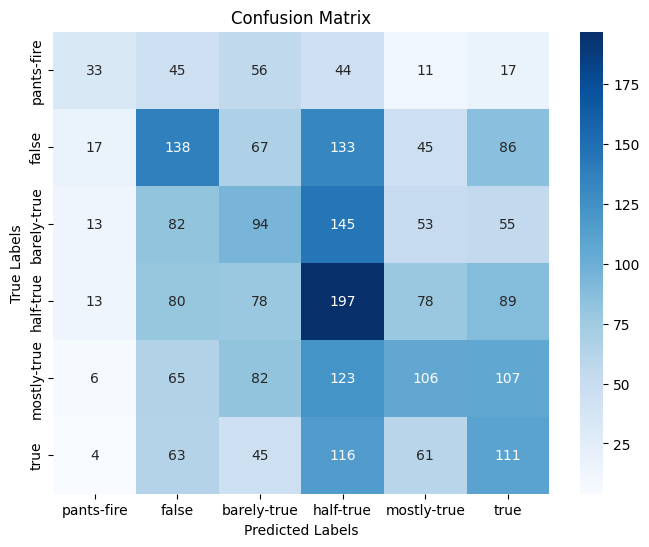

In [ ]:
# confusion Matrix for Test Set
conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_order, yticklabels=label_order)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# SHAP for feature explanations

  0%|          | 0/100 [00:00<?, ?it/s]

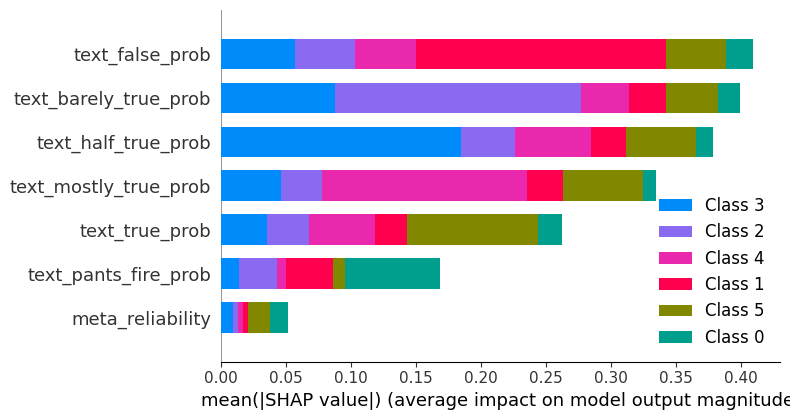

<Figure size 640x480 with 0 Axes>

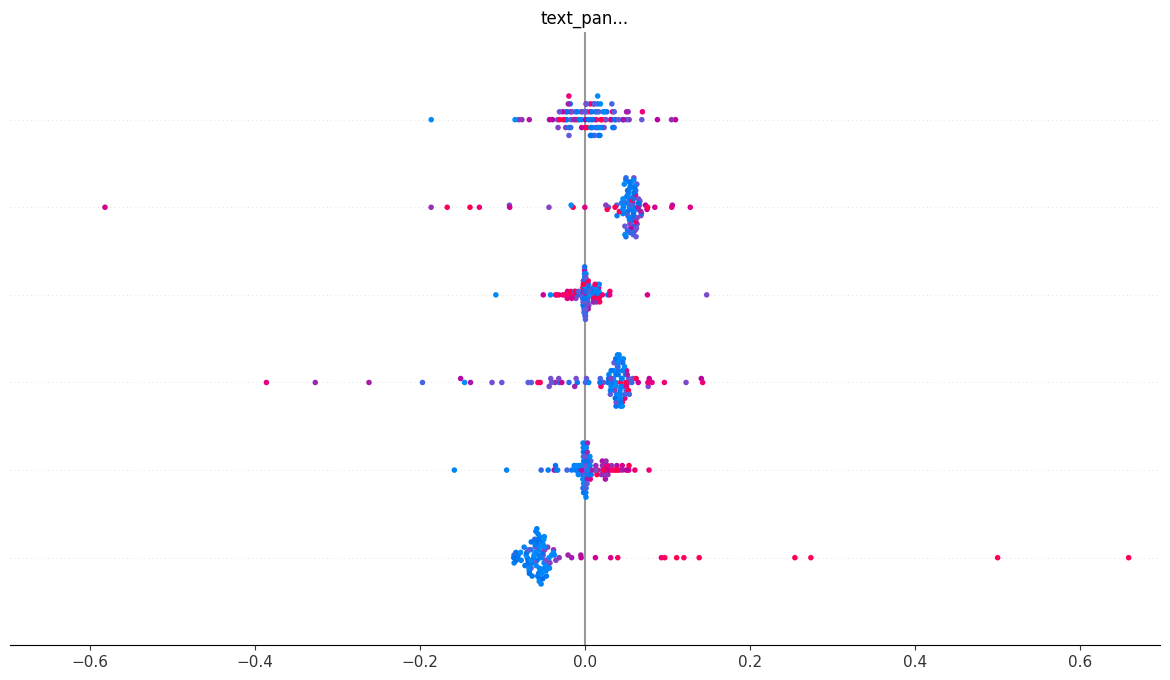

In [ ]:
import shap

# Initialize SHAP KernelExplainer for MLPClassifier
explainer = shap.KernelExplainer(best_mlp.predict_proba, X_train)

# Compute SHAP values for a subset of the test set (for efficiency)
shap_values = explainer.shap_values(X_test.iloc[:100])  # Use a subset of test data for faster computation

# Global Feature Importance: Bar Plot
shap.summary_plot(shap_values, X_test.iloc[:100], plot_type="bar")

# Global Feature Importance: Beeswarm Plot
shap.summary_plot(shap_values, X_test.iloc[:100])